### Algoritmo de Colonia de Hormigas

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [77]:
## Funcion a optimizar
fx = lambda t: 204165.5/(330 - 2*t) + 10400/(t-20) 

In [78]:
rastrigin = lambda x: 10 + x**2 - 10 * np.cos(2 * np.pi * x)

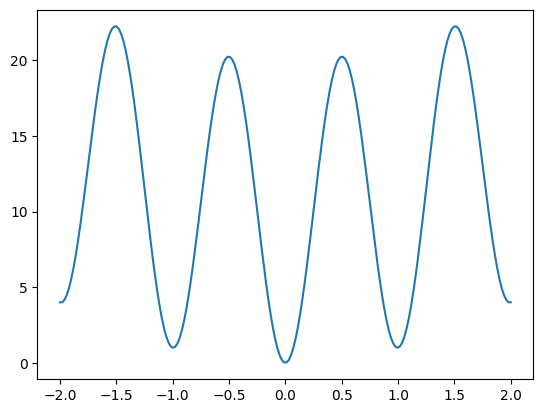

In [89]:
t = np.linspace(-2, 2, 200)
plt.plot(t, rastrigin(t))

In [80]:
# Limites del dominio
T_MIN = -2
T_MAX = 2

ARCHIVE_SIZE = 20   # número de soluciones almacenadas en el archivo
NUM_ANTS = 20       # número de hormigas por iteración
MAX_ITER = 50 # Iterations
SIGMA = 5.0         # Amplitud de muestreo (fija)

In [81]:
def evaluar(t):
    if t <= T_MIN or t >= T_MAX:
        return float('inf')
    else:
        return float(rastrigin(t))

In [82]:
def inicializar_archivo():
    archivo = []
    for _ in range(ARCHIVE_SIZE):
        t = random.uniform(T_MIN, T_MAX)
        fitness = evaluar(t)
        archivo.append((t, fitness))
        archivo.sort(key=lambda x: x[1]) # Menor fitness primero
    return archivo

In [83]:
def seleccionar_solucion(archivo):
    k = len(archivo)
    pesos = list(range(k, 0, -1))  # Soluciones mejores tienen más peso
    total = sum(pesos)
    probs = [p / total for p in pesos]
    idx = random.choices(range(k), weights=probs, k=1)[0]
    return archivo[idx][0]  # Retorna el valor de t

In [84]:
def generar_nueva_solucion(t_guia):
    t = np.random.normal(t_guia, SIGMA)
    t = max(T_MIN, min(T_MAX, t))  # Asegura que esté dentro del dominio
    return t

In [92]:
def aco_simple():
    archivo = inicializar_archivo()
    mejor_t, mejor_f = archivo[0]

    print("Iteración | mejor t | f(t)")
    print("-" * 35)

    for it in range(MAX_ITER):
        nuevas_soluciones = []

    # Cada hormiga genera una solución
    for _ in range(NUM_ANTS):
        t_guia = seleccionar_solucion(archivo)
        t_nueva = generar_nueva_solucion(t_guia)
        f_nueva = evaluar(t_nueva)
        nuevas_soluciones.append((t_nueva, f_nueva))

    # Combinar archivo actual con nuevas soluciones
    todas = archivo + nuevas_soluciones
    todas.sort(key=lambda x: x[1]) # Ordenar por fitness
    archivo = todas[:ARCHIVE_SIZE] # Conservar las mejores

    # Actualizar mejor global
    if archivo[0][1] < mejor_f:
        mejor_t, mejor_f = archivo[0]

    print(f"{it+1:8d} | {mejor_t:10.5f} | {mejor_f:10.5f}")
    return mejor_t, mejor_f 

if __name__ == "__main__":
    print("Optimización continua con Algoritmo de Colonia de Hormigas (ACO_R simplificado)\n")
    print("\n--- Resultado ---")
    mejor_t, mejor_f = aco_simple()
    print(f"Mejor t encontrado: {mejor_t:.6f}")
    print(f"Valor mínimo de f(t): {mejor_f:.6f}")

Optimización continua con Algoritmo de Colonia de Hormigas (ACO_R simplificado)


--- Resultado ---
Iteración | mejor t | f(t)
-----------------------------------
      50 |    1.00384 |    1.01059
Mejor t encontrado: 1.003835
Valor mínimo de f(t): 1.010589
